<a href="https://colab.research.google.com/github/sergio1/estudos/blob/main/UC_02_Lab_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1 - Importação das bibliotecas
import warnings, requests, zipfile, io  # warnings (avisos)
                                        # requests (requisição web)
                                        # zipfiles (arquivos zip)
                                        # io (entrada/saida em memória)
import pandas as pd                     # Manipulação de dados em tabelas
from scipy.io import arff               # Importa função para ler arquivos ARFF

# Ignorar mensagens de aviso (warnings) para não poluir a saída do programa
warnings.simplefilter('ignore')

In [6]:
# 2 - Importar arquivos
# URL do arqivo ZIP com dataset "Vertebral Column" no repositorio da UCI
f_zip = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip'

# Faz download do arquivo ZIP a partir da URL
# A parâmentro strem=TRue baixa o conteudo em partes(útil para arquivos grandes)
r = requests.get(f_zip, stream=True) # Faz a requisição do arquivo ZIP

# Converter o contéudo baixado(r.content) em um arquivo em memória(BytesIO)
# e abre como um arquivo ZIP para manipulação
vertebral_zip = zipfile.ZipFile(io.BytesIO(r.content))

# extrair todos os arquivos do ZIP para diretorio atual
vertebral_zip.extractall()


In [7]:
# 3 - Leitura de arquivos

# Lê o arquivo ARFF extraido (formato usado no WEKA) e carregar os dados
data = arff.loadarff('column_2C_weka.arff')

# Criar m data frame do pandas com os dados carregados
df = pd.DataFrame(data[0])

# Mostrar as 5 primeiras linhas do DataFrame para vizualizar
df.head()


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,b'Abnormal'
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,b'Abnormal'
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,b'Abnormal'
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,b'Abnormal'
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,b'Abnormal'


In [8]:
# 4 - Explorção de dados

df.shape # Função que examina o numero de linhas e colunas


(310, 7)

In [9]:
# 5 - Listando Colunas
df.columns

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')

In [11]:
# 6 - Verificando o tipo de dados das colunas
df.dtypes

,0
pelvic_incidence,float64
pelvic_tilt,float64
lumbar_lordosis_angle,float64
sacral_slope,float64
pelvic_radius,float64
degree_spondylolisthesis,float64
class,object


In [13]:
# 7 - Examinar as estatisticas
df['pelvic_incidence'].describe()


,pelvic_incidence
count,310.000000
mean,60.496653
std,17.236520
min,26.147921
25%,46.430294
50%,58.691038
75%,72.877696
max,129.834041


In [14]:
# 8 - Exibindo a estatistica de cada compenente
df.describe()


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [22]:
# 9 - Plotando os valores
# Importando a biblioteca Matplot.lib, módulo pyplot, que fornece interface para criar gráficos.
import matplotlib.pyplot as plt

%matplotlib inline  #Comand que garante que o gráfico grados sejam exibidos dentro do notebook
# criando grafico
df.plot()



UsageError: unrecognized arguments: #Comand que garante que o gráfico grados sejam exibidos dentro do notebook


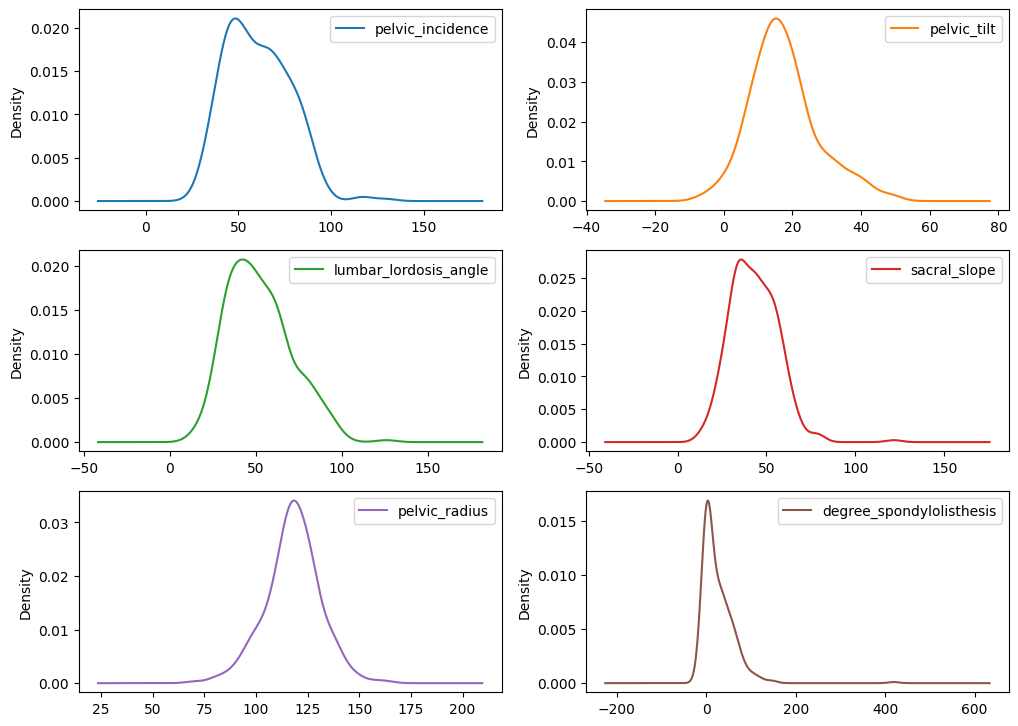

In [18]:
# 10 0 Plotando os valores para cada componente

# chama o método .plot() do Pandas. O parametro
df.plot(kind='density', subplots=True, layout=(4,2), figsize=(12,12),sharex=False)
plt.show()

<Axes: ylabel='Density'>

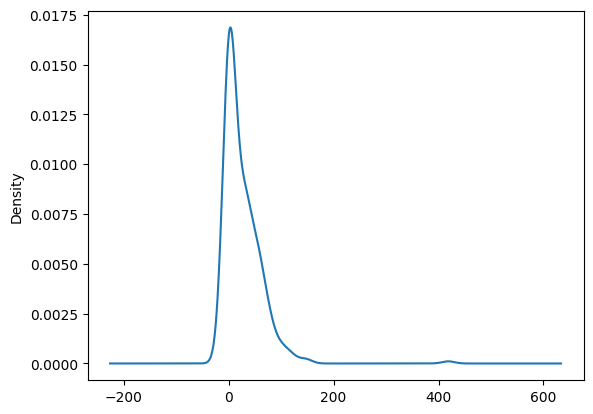

In [20]:
# 11 - Investigar a visualização
df['degree_spondylolisthesis'].plot.density()

<Axes: ylabel='Frequency'>

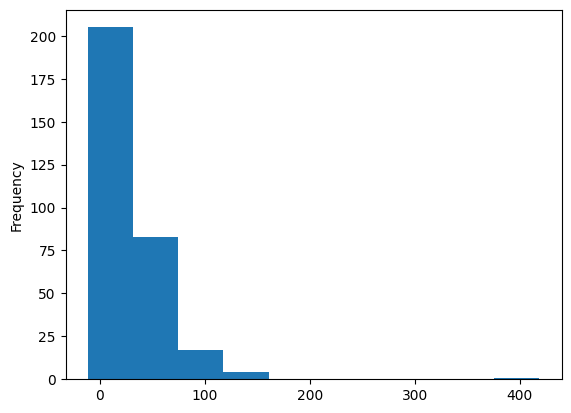

In [21]:
# 12 - Vizualizando com histograma
df['degree_spondylolisthesis'].plot.hist()

<Axes: >

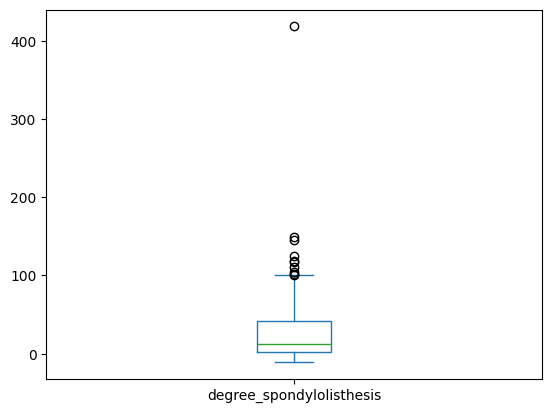

In [23]:
# 13 - Visualização anomalias
df['degree_spondylolisthesis'].plot.box()


In [24]:
# 14 - Analizar o nosso target(alvo)
df['class'].value_counts()


,count
class,
b'Abnormal',210
b'Normal',100


In [25]:
# 15 - Mapeando
class_mapper = {b'Abnormal':1, b'Normal':0}
df['class'] = df['class'].map(class_mapper)
df

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,0
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,0
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,0
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,0


<Axes: xlabel='class', ylabel='degree_spondylolisthesis'>

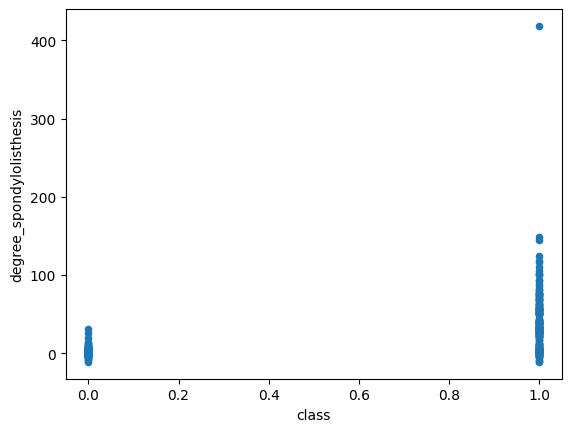

In [26]:
#  16 - Plotando o degree_spon
df.plot.scatter(x='class', y='degree_spondylolisthesis')

,0
0,"Axes(0.1,0.15;0.363636x0.75)"
1,"Axes(0.536364,0.15;0.363636x0.75)"


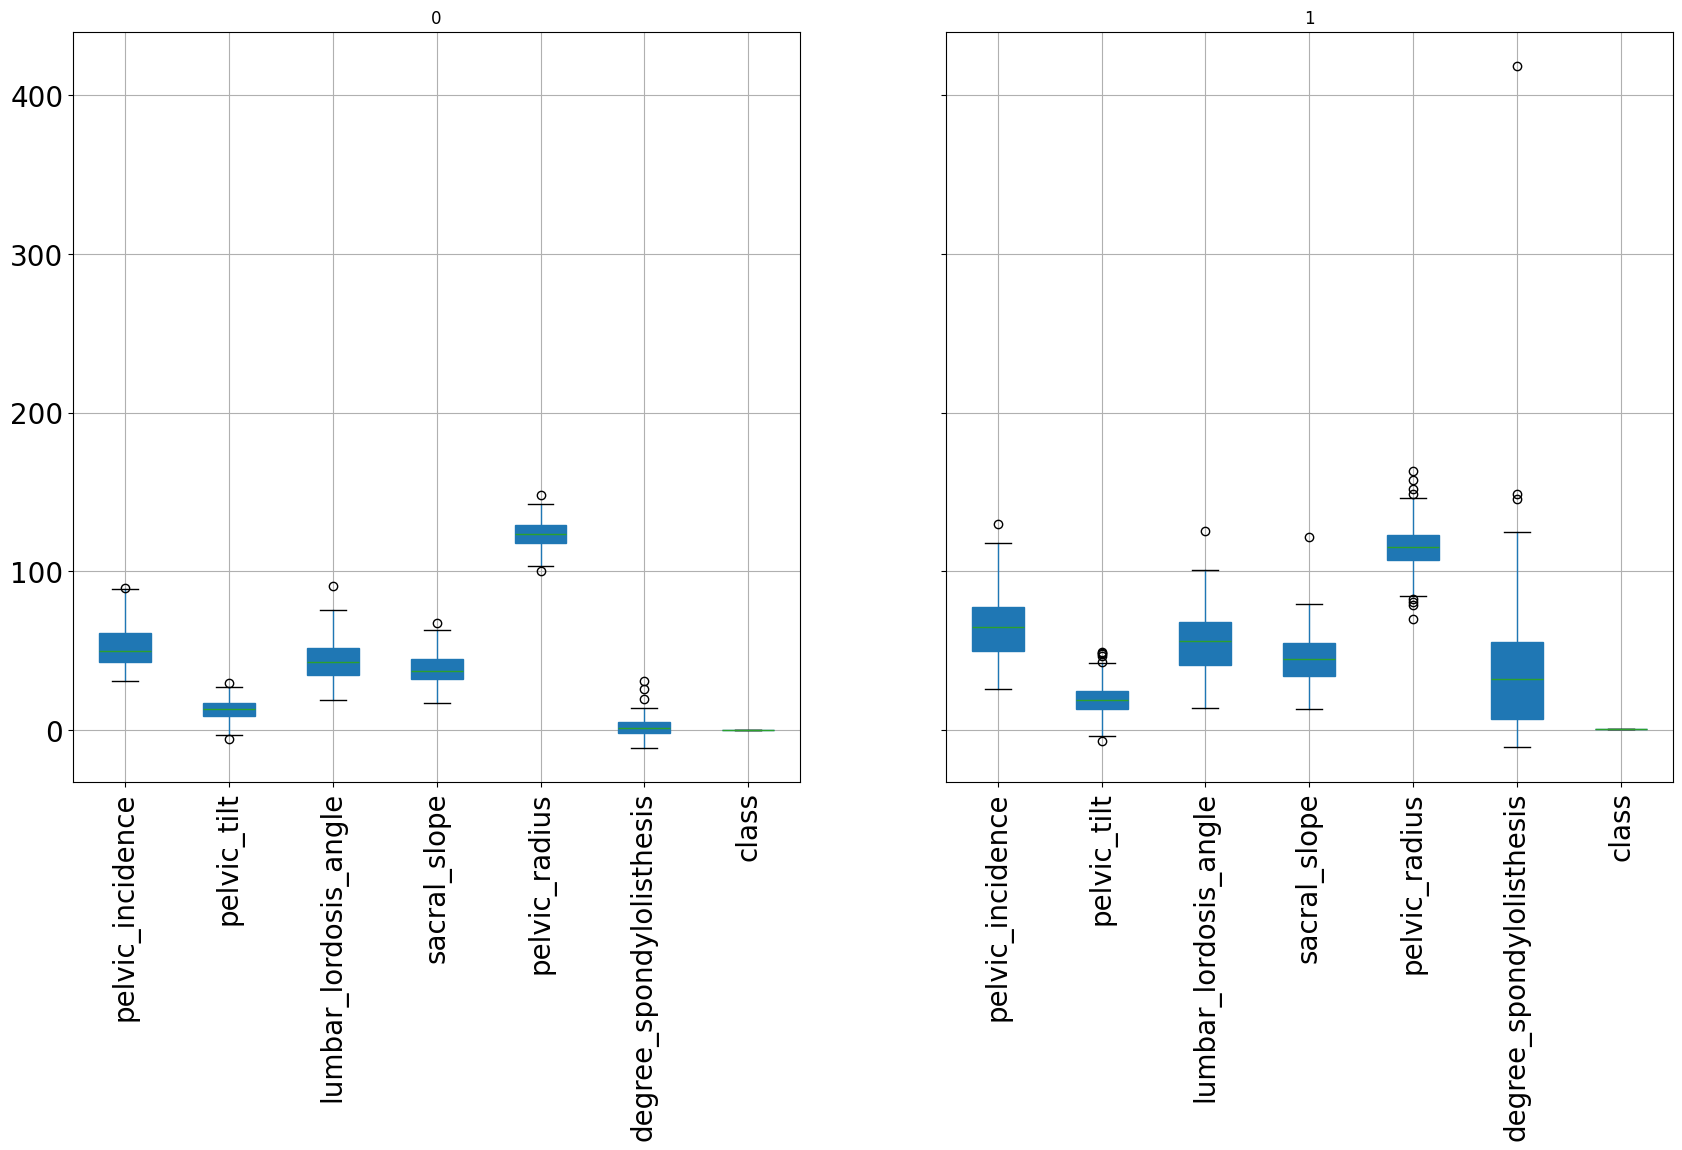

In [27]:
# 17 - Visualizando variaveis
df.groupby('class').boxplot(fontsize=20, rot=90, figsize=(20,10), patch_artist=True)

In [29]:
# 18 - Criando a Matriz
corr_matrix = df.corr(numeric_only=True)
corr_matrix['class'].sort_values(ascending=False)


,class
class,1.000000
degree_spondylolisthesis,0.443687
pelvic_incidence,0.353336
pelvic_tilt,0.326063
lumbar_lordosis_angle,0.312484
sacral_slope,0.210602
pelvic_radius,-0.309857


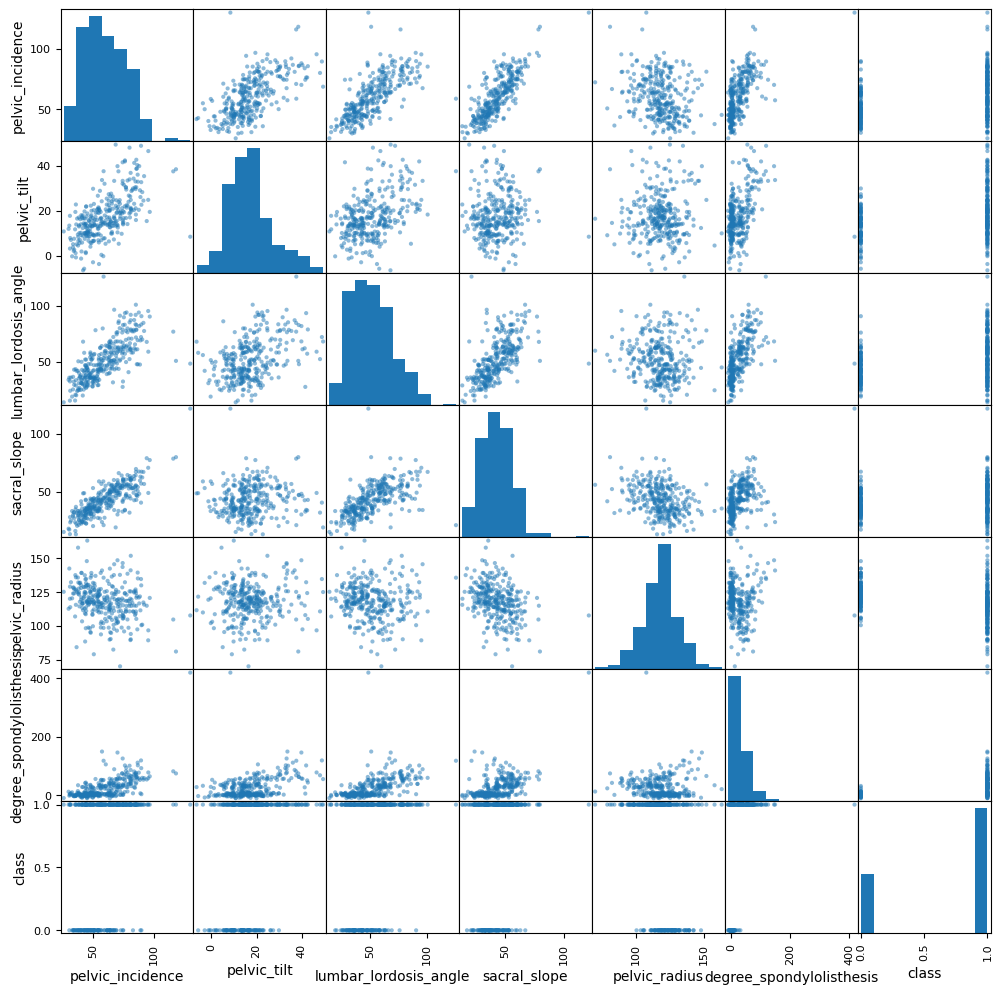

In [30]:
# 19 - Plotando os dados da matriz
pd.plotting.scatter_matrix(df, figsize=(12,12))
plt.show()


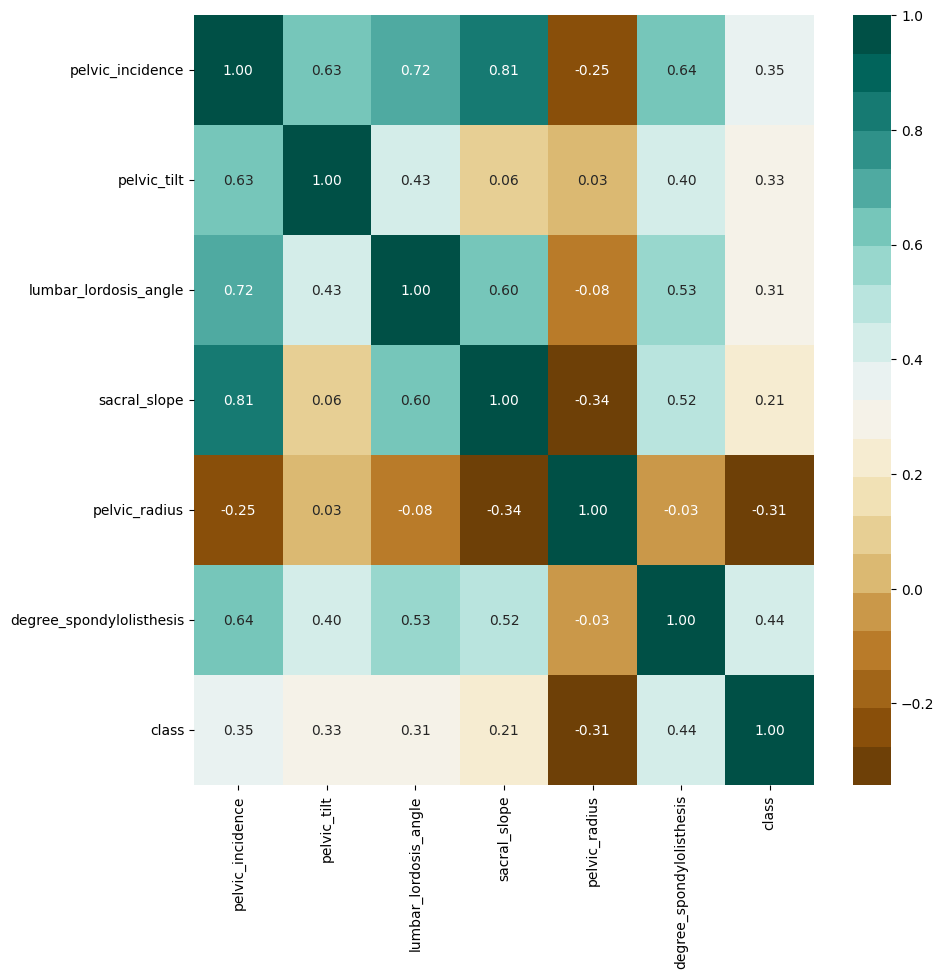

In [31]:
# 20 - Visualizando correlação com o heatmap(Mapa de calor)
import seaborn as sns

fix, ax = plt.subplots(figsize=(10,10))
colormap = sns.color_palette('BrBG',20)
sns.heatmap(corr_matrix, annot=True, cmap=colormap, fmt='.2f')
plt.show()
